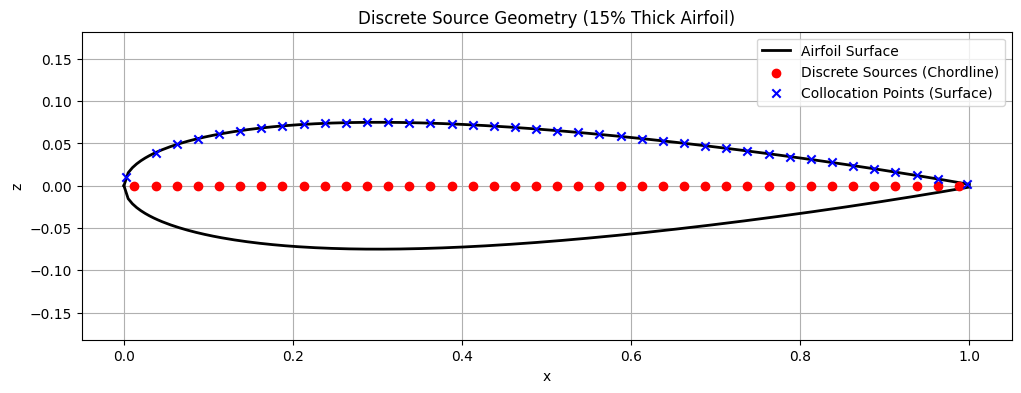

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. PARAMETERS

N = 40          # Number of panels / discrete sources
U_inf = 1.0     # Freestream velocity

# 2. GEOMETRY DISCRETIZATION

# 15% Thick Symmetric Airfoil (NACA 0015)
def naca0015_thickness(x):
    t = 0.15
    x = np.clip(x, 0, 1)
    return 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1015 * x**4)

# Derivative of the surface for calculating normal vectors
def naca0015_dzdx(x):
    t = 0.15
    x = np.clip(x, 1e-6, 1) # Prevent divide-by-zero at leading edge
    return 5 * t * (0.5 * 0.2969 / np.sqrt(x) - 0.1260 - 2 * 0.3516 * x + 3 * 0.2843 * x**2 - 4 * 0.1015 * x**3)

x_nodes = np.linspace(0, 1, N+1)

# Discrete Sources: Placed exactly on the x-axis (z=0) at the center of each segment
x_source = 0.5 * (x_nodes[:-1] + x_nodes[1:])
z_source = np.zeros(N)

# Collocation Points: Placed on the physical upper surface of the airfoil
x_collocation = np.copy(x_source)

# PDF IMPROVEMENT (Fig 11.14):
# Shift the 1st and last collocation points to improve leading/trailing edge accuracy
x_collocation[0] = x_nodes[0] + 0.1 * (x_nodes[1] - x_nodes[0])
x_collocation[-1] = x_nodes[-1] - 0.1 * (x_nodes[-1] - x_nodes[-2])
z_collocation = naca0015_thickness(x_collocation)

# Plot the Geometry
plt.figure(figsize=(12, 4))
x_plot = np.linspace(0, 1, 200)
plt.plot(x_plot, naca0015_thickness(x_plot), '-k', linewidth=2, label='Airfoil Surface')
plt.plot(x_plot, -naca0015_thickness(x_plot), '-k', linewidth=2)
plt.scatter(x_source, z_source, color='red', marker='o', zorder=5, label='Discrete Sources (Chordline)')
plt.scatter(x_collocation, z_collocation, color='blue', marker='x', zorder=5, label='Collocation Points (Surface)')
plt.axis('equal')
plt.title('Discrete Source Geometry (15% Thick Airfoil)')
plt.xlabel('x')
plt.ylabel('z')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# ==========================================
# 3. NORMAL & TANGENT VECTORS
# ==========================================
dzdx = naca0015_dzdx(x_collocation)
mag = np.sqrt(1 + dzdx**2)

# Outward pointing normal vectors (Upper Surface)
nx = -dzdx / mag
nz = 1.0 / mag

# Tangent vectors
tx = 1.0 / mag
tz = dzdx / mag

# ==========================================
# 4. BUILD INFLUENCE MATRIX (A) AND RHS (b)
# ==========================================
A = np.zeros((N, N))
b = np.zeros(N)

for i in range(N):
    # Right Hand Side: Zero normal velocity boundary condition
    b[i] = -U_inf * nx[i]

    for j in range(N):
        delx = x_collocation[i] - x_source[j]
        delz = z_collocation[i] - z_source[j]
        r_squared = max(delx**2 + delz**2, 1e-10)

        # Velocity components induced by a unit source (Eq 11.15)
        u_ij = (1 / (2 * np.pi)) * (delx / r_squared)
        w_ij = (1 / (2 * np.pi)) * (delz / r_squared)

        # Dot product with normal vector
        A[i, j] = (u_ij * nx[i]) + (w_ij * nz[i])

# Solve for the unknown Source Strengths (Sigma)
sigma = np.linalg.solve(A, b)

# Verify net source strength (Should be close to zero for closed bodies)
print(f"Net Source Flow (Sum of Sigma): {np.sum(sigma):.5f}")

Net Source Flow (Sum of Sigma): -0.01173


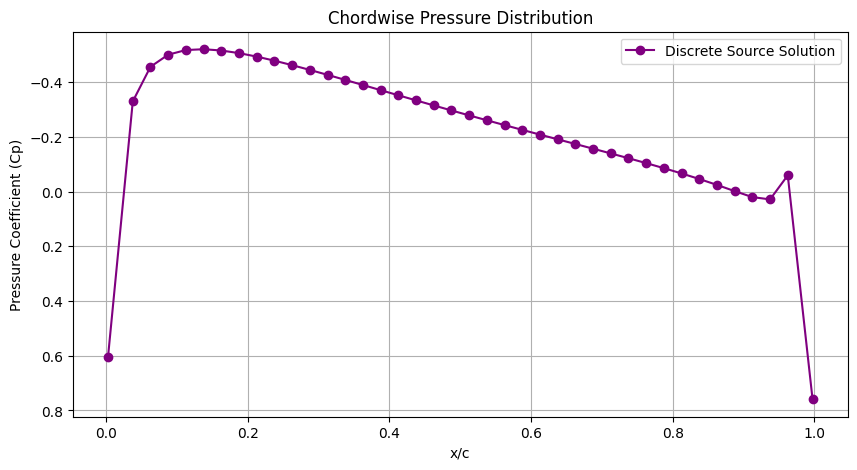

In [3]:
# ==========================================
# 5. TANGENTIAL VELOCITY & PRESSURE (Cp)
# ==========================================
Vt = np.zeros(N)

for i in range(N):
    Vt[i] = U_inf * tx[i]
    for j in range(N):
        delx = x_collocation[i] - x_source[j]
        delz = z_collocation[i] - z_source[j]
        r_squared = max(delx**2 + delz**2, 1e-10)

        u_ij = (1 / (2 * np.pi)) * (delx / r_squared)
        w_ij = (1 / (2 * np.pi)) * (delz / r_squared)

        Vt[i] += sigma[j] * (u_ij * tx[i] + w_ij * tz[i])

# Calculate Pressure Coefficient
Cp = 1 - (Vt / U_inf)**2

plt.figure(figsize=(10, 5))
plt.plot(x_collocation, Cp, '-o', color='purple', label='Discrete Source Solution')
plt.gca().invert_yaxis() # Aerodynamic standard: negative Cp up
plt.xlabel('x/c')
plt.ylabel('Pressure Coefficient (Cp)')
plt.title('Chordwise Pressure Distribution')
plt.grid(True)
plt.legend()
plt.show()

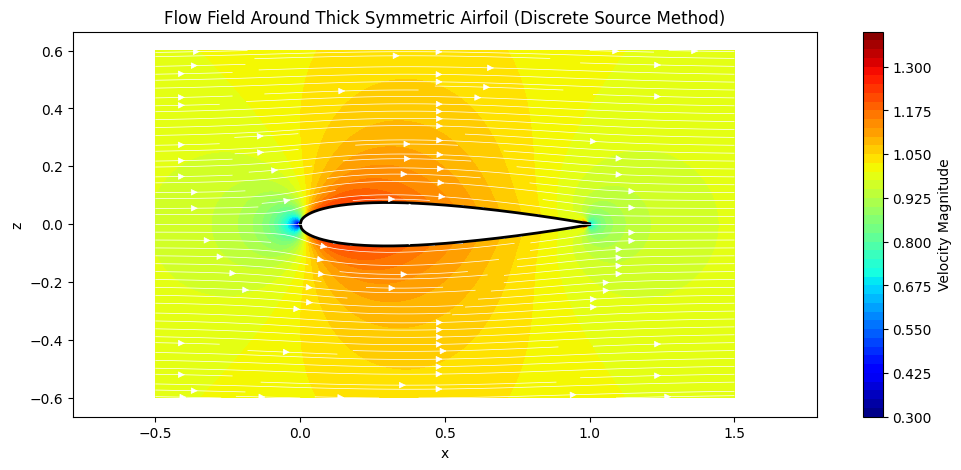

In [4]:
# ==========================================
# 6. STREAMLINES & VELOCITY CONTOURS
# ==========================================
X, Z = np.meshgrid(
    np.linspace(-0.5, 1.5, 200),
    np.linspace(-0.6, 0.6, 150)
)

U = U_inf * np.ones_like(X)
W = np.zeros_like(Z)

for j in range(N):
    delx = X - x_source[j]
    delz = Z - z_source[j]
    r_squared = delx**2 + delz**2

    # Prevent singularities exactly at the source points
    r_squared[r_squared < 1e-5] = 1e-5

    u_ind = (sigma[j] / (2 * np.pi)) * (delx / r_squared)
    w_ind = (sigma[j] / (2 * np.pi)) * (delz / r_squared)

    U += u_ind
    W += w_ind

vel_mag = np.sqrt(U**2 + W**2)

# Mask out internal velocity (inside the airfoil) for cleaner contours
thickness_grid = naca0015_thickness(X)
inside_mask = (X >= 0) & (X <= 1) & (np.abs(Z) <= thickness_grid)
vel_mag[inside_mask] = np.nan

plt.figure(figsize=(12, 5))
contour = plt.contourf(X, Z, vel_mag, levels=50, cmap='jet')
plt.colorbar(contour, label='Velocity Magnitude')

plt.plot(x_plot, naca0015_thickness(x_plot), '-k', linewidth=2)
plt.plot(x_plot, -naca0015_thickness(x_plot), '-k', linewidth=2)
plt.streamplot(X, Z, U, W, density=1.5, color='white', linewidth=0.5)

plt.axis('equal')
plt.xlabel('x')
plt.ylabel('z')
plt.title('Flow Field Around Thick Symmetric Airfoil (Discrete Source Method)')
plt.show()